# JBI100 Visualization 
### Academic year 2025-2026

## Health and Global Statistics
Data sources:

- Hospital Beds Management (https://www.kaggle.com/datasets/jaderz/hospital-beds-management/data)
- CIA Global Statistical Database (https://www.kaggle.com/datasets/kushagraarya10/cia-global-statistical-database)

Data dictionaries and additional info can be found in the respective data folders.
Note: you only need to select one dataset for your project; the dataset that you choose consists of multiple CSV files.

In [2]:
# Import libraries
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import plotly.io as pio

from functools import reduce

# Render plotly in IFrame
pio.renderers.default = 'iframe'

# Do not truncate tables
pd.set_option('display.max_columns', None)

# If you receive a 'ModuleNotFoundError' please install the according library. 
# This can be done from within the Jupyter environment with the command 
#'!python -m pip install lib' where lib is the according library name.

In [3]:
import os
from pathlib import Path

os.getcwd()

'c:\\Users\\muham\\visualization-13'

In [4]:
# Load the data
# CIA Global Statistical Database
df_CIA_communications        = pd.read_csv('./CIA Global Statistical Database/communications_data.csv', delimiter=',', low_memory=False)
df_CIA_demographics          = pd.read_csv('./CIA Global Statistical Database/demographics_data.csv', delimiter=',', low_memory=False)
df_CIA_economy               = pd.read_csv('./CIA Global Statistical Database/economy_data.csv', delimiter=',', low_memory=False)
df_CIA_energy                = pd.read_csv('./CIA Global Statistical Database/energy_data.csv', delimiter=',', low_memory=False)
df_CIA_geography             = pd.read_csv('./CIA Global Statistical Database/geography_data.csv', delimiter=',', low_memory=False)
df_CIA_government_and_civics = pd.read_csv('./CIA Global Statistical Database/government_and_civics_data.csv', delimiter=',', low_memory=False)
df_CIA_transportation        = pd.read_csv('./CIA Global Statistical Database/transportation_data.csv', delimiter=',', low_memory=False)

## Explore CIA Global Statistical Database

In [5]:
df_CIA_demographics.sample(5)

,Country,Total_Population,Population_Growth_Rate,Birth_Rate,Death_Rate,Net_Migration_Rate,Median_Age,Sex_Ratio,Infant_Mortality_Rate,Total_Fertility_Rate,Total_Literacy_Rate,Male_Literacy_Rate,Female_Literacy_Rate,Youth_Unemployment_Rate
174,OMAN,3833465,1.8%,21.62,3.21,0.46,26.2,1.16,14.16,2.67,95.7%,15.5%,0.4%,14.6%
63,CYPRUS,1308120,1%,10.37,6.99,6.65,37.9,0.93,8.20,1.48,99.4%,47%,23.2%,11.8%
43,CAMEROON,30135732,2.73%,35.13,7.54,0.30,18.5,0.99,47.40,4.50,77.1%,13.2%,1.4%,6.6%
188,QATAR,2532104,0.86%,9.27,1.42,0.78,33.7,3.34,6.46,1.90,93.5%,21.7%,1.9%,1.1%
204,SERBIA,6693375,0.63%,8.90,15.10,0.00,43.7,0.95,4.60,1.46,99.5%,40.5%,39.1%,30.4%


In [6]:
df_CIA_demographics.describe()

,Birth_Rate,Death_Rate,Net_Migration_Rate,Median_Age,Sex_Ratio,Infant_Mortality_Rate,Total_Fertility_Rate
count,228.000000,230.000000,229.000000,227.000000,227.000000,227.000000,227.000000
mean,26.361842,25.018565,3.657511,31.833480,1.004229,19.367665,11.292555
std,132.909844,187.367894,5.565715,9.236467,0.187592,18.431299,133.983614
min,5.800000,1.420000,-2.400000,14.800000,0.830000,1.500000,1.090000
25%,10.800000,5.702500,0.630000,24.050000,0.950000,5.755000,1.680000
50%,15.030000,7.255000,1.890000,31.700000,0.980000,12.000000,1.970000
75%,22.225000,9.100000,4.400000,39.500000,1.010000,28.525000,2.800000
max,2020.000000,2021.000000,45.800000,55.400000,3.340000,103.060000,2021.000000


In [7]:
fig = px.bar(df_CIA_demographics, x="Country", y="Total_Population", color="Median_Age", color_continuous_scale='Viridis',
                   log_y=True,width=1500, height=800).update_xaxes(categoryorder="total descending")
fig.show()

## Combining usefull features into 1 database

In [8]:
# make sure the key column is named 'Country' everywhere
dfs = [
    df_CIA_communications,
    df_CIA_demographics,
    df_CIA_economy,
    df_CIA_energy,
    df_CIA_geography,
    df_CIA_government_and_civics,
    df_CIA_transportation,
]

# ---- COMMUNICATIONS ----
comm_cols = [
    'Country',
    'internet_users_total',
    'broadband_fixed_subscriptions_total',
    'mobile_cellular_subscriptions_total',
]
df_comm = df_CIA_communications[comm_cols].copy()

# ---- DEMOGRAPHICS ----
demo_cols = [
    'Country',
    'Total_Population',
    'Population_Growth_Rate',
    'Median_Age',
    'Total_Literacy_Rate',
    # add age structure etc. if you have it
]
df_demo = df_CIA_demographics[demo_cols].copy()

# ---- ECONOMY ----
econ_cols = [
    'Country',
    'Real_GDP_PPP_billion_USD',
    'Real_GDP_per_Capita_USD',
    'Real_GDP_Growth_Rate_percent',
    'Unemployment_Rate_percent',
    'Youth_Unemployment_Rate_percent',
    'Public_Debt_percent_of_GDP',
    'Budget_Deficit_percent_of_GDP',
    # trade fields if you want them
]
df_econ = df_CIA_economy[econ_cols].copy()

# ---- ENERGY ----
energy_cols = [
    'Country',
    'electricity_access_percent',
    'electricity_generating_capacity_kW',
    'coal_metric_tons',
    'refined_petroleum_exports_bbl_per_day', 
    'refined_petroleum_imports_bbl_per_day',
    'natural_gas_cubic_meters',
    'carbon_dioxide_emissions_Mt',
]
df_energy = df_CIA_energy[energy_cols].copy()

# ---- GEOGRAPHY ----
geo_cols = [
    'Country',
    'Area_Total',
    'Land_Area',
    'Water_Area',
    'Coastline',
    'Land_Boundaries',
    'Forest_Land',
]
df_geo = df_CIA_geography[geo_cols].copy()

# ---- GOVERNMENT & CIVICS ----
gov_cols = [
    'Country',
    'Government_Type',
    'Capital',
    'Capital_Coordinates',
    'Suffrage_Age',
]
df_gov = df_CIA_government_and_civics[gov_cols].copy()

# ---- TRANSPORTATION ----
trans_cols = [
    'Country',
    'roadways_km',
    'water_pipelines_km',
    'railways_km',
    'waterways_km',
    'gas_pipelines_km',
    'oil_pipelines_km',
    'refined_products_pipelines_km',
    'airports_paved_runways_count',
    'airports_unpaved_runways_count',
    'heliports_count',
]
df_trans = df_CIA_transportation[trans_cols].copy()

In [9]:
dfs_to_merge = [
    df_comm,
    df_demo,
    df_econ,
    df_energy,
    df_geo,
    df_gov,
    df_trans,
]

df_combined = reduce(
    lambda left, right: pd.merge(left, right, on='Country', how='outer'),
    dfs_to_merge
)

print(df_combined.shape)
df_combined.head()




(259, 42)


,Country,internet_users_total,broadband_fixed_subscriptions_total,mobile_cellular_subscriptions_total,Total_Population,Population_Growth_Rate,Median_Age,Total_Literacy_Rate,Real_GDP_PPP_billion_USD,Real_GDP_per_Capita_USD,Real_GDP_Growth_Rate_percent,Unemployment_Rate_percent,Youth_Unemployment_Rate_percent,Public_Debt_percent_of_GDP,Budget_Deficit_percent_of_GDP,electricity_access_percent,electricity_generating_capacity_kW,coal_metric_tons,refined_petroleum_exports_bbl_per_day,refined_petroleum_imports_bbl_per_day,natural_gas_cubic_meters,carbon_dioxide_emissions_Mt,Area_Total,Land_Area,Water_Area,Coastline,Land_Boundaries,Forest_Land,Government_Type,Capital,Capital_Coordinates,Suffrage_Age,roadways_km,water_pipelines_km,railways_km,waterways_km,gas_pipelines_km,oil_pipelines_km,refined_products_pipelines_km,airports_paved_runways_count,airports_unpaved_runways_count,heliports_count
0,AFGHANISTAN,7020000,26570.0,23000000.0,39232003,2.26%,19.5,37.3%,60.80,1500.0,-20.74,13.28,20.2,7.00,-15.1,97.0,776000.0,2096000.0,0.0,34210.0,8.019300e+07,7893000.0,"652,230 sq km","652,230 sq km",0 sq km,0 km,"5,987 km",1.8%,Theocracy,Kabul,"34 31 N, 69 11 E",18.0,34903,NaN,NaN,1200,466.0,NaN,NaN,29,17,1
1,AKROTIRI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123 sq km,NaN,NaN,56.3 km,48 km,NaN,NaN,Episkopi Cantonment,"34 40 N, 32 51 E",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ALBANIA,2291000,508937.0,2635466.0,3101621,0.19%,34.3,98.4%,40.82,14500.0,8.52,11.82,27.8,84.06,-2.0,100.0,2531000.0,9000.0,3250.0,26660.0,4.205000e+07,3.0,"28,748 sq km","27,398 sq km","1,350 sq km",362 km,691 km,28.8%,Republic,Tirana,"41 19 N, 19 49 E",18.0,3945,NaN,424,41,498.0,NaN,NaN,3,NaN,NaN
3,ALGERIA,31240000,3790459.0,47028685.0,44758398,1.27%,28.9,81.4%,487.72,11000.0,3.50,12.70,31.9,27.50,-9.6,99.0,21694000.0,0.0,578800.0,82930.0,8.785398e+10,151.0,"2,381,740 sq km","2,381,740 sq km",0 sq km,998 km,"6,734 km",0.8%,Republic,Algiers,"36 45 N, 3 03 E",18.0,104000,NaN,4020,NaN,16415.0,7036.0,NaN,67,82,4
4,AMERICAN SAMOA,18135,NaN,2250.0,44620,1.74%,27.2,NaN,658.00,11200.0,-1.87,29.80,NaN,12.20,-2.1,59.0,47000.0,NaN,0.0,2346.0,NaN,355000.0,224 sq km,224 sq km,0 sq km,116 km,0 km,75.5%,Republic,Pago Pago,"14 16 S, 170 42 W",18.0,241,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN


In [10]:
df_master = df_combined


## Getting rid of countries with crucial missing values
##### We excluded 49 countries due to missing core data such as population, Internet users, and electricity access %. etc.

In [11]:
required_cols = [
    'Total_Population',
    'electricity_access_percent',
    'internet_users_total',
    'Real_GDP_per_Capita_USD',
    'Area_Total',
]

print("Rows before dropping:", df_master.shape)
df_master = df_master.dropna(subset=required_cols)
df_master = df_master.drop(index=254) #west bank
df_master = df_master.drop(index=255) #world
print("Rows after dropping:", df_master.shape)

missing_required = df_combined[df_combined[required_cols].isna().any(axis=1)]
missing_required[['Country'] + required_cols].head()

df_master.tail()



Rows before dropping: (259, 42)
Rows after dropping: (208, 42)


,Country,internet_users_total,broadband_fixed_subscriptions_total,mobile_cellular_subscriptions_total,Total_Population,Population_Growth_Rate,Median_Age,Total_Literacy_Rate,Real_GDP_PPP_billion_USD,Real_GDP_per_Capita_USD,Real_GDP_Growth_Rate_percent,Unemployment_Rate_percent,Youth_Unemployment_Rate_percent,Public_Debt_percent_of_GDP,Budget_Deficit_percent_of_GDP,electricity_access_percent,electricity_generating_capacity_kW,coal_metric_tons,refined_petroleum_exports_bbl_per_day,refined_petroleum_imports_bbl_per_day,natural_gas_cubic_meters,carbon_dioxide_emissions_Mt,Area_Total,Land_Area,Water_Area,Coastline,Land_Boundaries,Forest_Land,Government_Type,Capital,Capital_Coordinates,Suffrage_Age,roadways_km,water_pipelines_km,railways_km,waterways_km,gas_pipelines_km,oil_pipelines_km,refined_products_pipelines_km,airports_paved_runways_count,airports_unpaved_runways_count,heliports_count
250,VIETNAM,71780000,16699249.0,140000000.0,104799174,0.93%,32.7,95.8%,1036.00,10600.0,2.56,2.17,7.2,58.5,-6.7,100.0,65283000.0,47789000.0,25620.0,282800.0,8.438095e+09,249.0,"331,210 sq km","310,070 sq km","21,140 sq km","3,444 km","4,616 km",45%,Communist,Hanoi,"21 02 N, 105 51 E",18.0,195468,NaN,2600,47130,72.0,NaN,NaN,38,7,1
251,VIRGIN ISLANDS,67508,NaN,80000.0,104917,0.49%,42.7,NaN,3.87,37000.0,-2.15,13.27,27.0,53.3,-0.4,100.0,321000.0,NaN,3285.0,23480.0,NaN,2.0,"1,910 sq km",346 sq km,"1,564 sq km",188 km,0 km,57.4%,Republic,Charlotte Amalie,"18 21 N, 64 56 W",18.0,1260,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
256,YEMEN,8229624,391000.0,15000000.0,31565602,1.83%,21.6,70.1%,73.63,2500.0,-5.90,13.57,25.5,74.5,-5.2,74.0,1772000.0,0.0,12670.0,75940.0,8.990600e+07,10.0,"527,968 sq km","527,968 sq km",0 sq km,"1,906 km","1,601 km",1%,Other,Sanaa,"15 21 N, 44 12 E",18.0,71300,NaN,NaN,NaN,641.0,1370.0,NaN,17,40,NaN
257,ZAMBIA,3990000,82317.0,20000000.0,20216029,2.86%,18.2,86.7%,63.03,3200.0,4.60,13.03,26.1,103.7,-7.3,46.0,3065000.0,1116000.0,371.0,10150.0,NaN,6.0,"752,618 sq km","743,398 sq km","9,220 sq km",0 km,"6,043.15 km",66.3%,Republic,Lusaka,"15 25 S, 28 17 E",18.0,67671,NaN,3126,2250,NaN,771.0,NaN,8,80,NaN
258,ZIMBABWE,5600000,203461.0,14257590.0,15418674,1.99%,21.0,89.7%,33.83,2100.0,8.47,5.17,7.3,82.3,-9.6,48.0,2473000.0,3888000.0,NaN,26400.0,NaN,7.0,"390,757 sq km","386,847 sq km","3,910 sq km",0 km,"3,229 km",39.5%,Republic,Harare,"17 49 S, 31 02 E",18.0,97267,NaN,3427,223,NaN,NaN,NaN,17,179,NaN


### Temperature dataset from: Trading Economics. https://tradingeconomics.com/country-list/temperature.

In [12]:
df_temp = pd.DataFrame([
    ('Burkina Faso', 29.94),
    ('Mali', 29.69),
    ('Aruba', 29.63),
    ('Senegal', 29.41),
    ('Mauritania', 29.25),
    ('Djibouti', 29.22),
    ('Gambia', 28.84),
    ('Qatar', 28.70),
    ('Marshall Islands', 28.62),
    ('United Arab Emirates', 28.62),
    ('Bahrain', 28.57),
    ('Benin', 28.57),
    ('St Kitts and Nevis', 28.49),
    ('Guinea Bissau', 28.47),
    ('Cayman Islands', 28.45),
    ('Singapore', 28.41),
    ('Maldives', 28.37),
    ('Ghana', 28.36),
    ('Cambodia', 28.25),
    ('Antigua and Barbuda', 28.23),
    ('Oman', 28.22),
    ('Niger', 28.19),
    ('Samoa', 28.13),
    ('Togo', 28.06),
    ('Micronesia', 27.96),
    ('American Samoa', 27.92),
    ('Guam', 27.91),
    ('St Lucia', 27.88),
    ('Virgin Islands', 27.88),
    ('Sri Lanka', 27.86),
    ('Kiribati', 27.81),
    ('Palau', 27.81),
    ('Thailand', 27.79),
    ('Sudan', 27.73),
    ('Dominica', 27.70),
    ('Nigeria', 27.65),
    ('Seychelles', 27.64),
    ('Trinidad and Tobago', 27.62),
    ('Suriname', 27.60),
    ('Northern Mariana Islands', 27.49),
    ('Barbados', 27.41),
    ('Chad', 27.41),
    ('Ivory Coast', 27.38),
    ('Somalia', 27.28),
    ('Kuwait', 27.27),
    ('Grenada', 27.23),
    ('Eritrea', 27.19),
    ('Philippines', 27.16),
    ('Guyana', 27.11),
    ('St Vincent and the Grenadines', 27.07),
    ('Malaysia', 27.06),
    ('Sierra Leone', 26.99),
    ('Jamaica', 26.66),
    ('Belize', 26.63),
    ('Guinea', 26.60),
    ('Nicaragua', 26.56),
    ('Cuba', 26.42),
    ('Indonesia', 26.38),
    ('Saudi Arabia', 26.35),
    ('Bahamas', 26.28),
    ('Venezuela', 26.27),
    ('Bangladesh', 26.18),
    ('Panama', 26.13),
    ('Brazil', 26.02),
    ('El Salvador', 26.01),
    ('Yemen', 26.00),
    ('Liberia', 25.94),
    ('Solomon Islands', 25.89),
    ('Puerto Rico', 25.86),
    ('Haiti', 25.80),
    ('Gabon', 25.64),
    ('Tonga', 25.62),
    ('Dominican Republic', 25.60),
    ('Colombia', 25.58),
    ('Honduras', 25.54),
    ('Vietnam', 25.54),
    ('India', 25.43),
    ('Mayotte', 25.43),
    ('Central African Republic', 25.42),
    ('Fiji', 25.33),
    ('Republic of the Congo', 25.28),
    ('Kenya', 25.23),
    ('Costa Rica', 25.21),
    ('Mozambique', 25.18),
    ('Cameroon', 25.12),
    ('Laos', 25.05),
    ('Equatorial Guinea', 25.03),
    ('Paraguay', 24.85),
    ('Papua New Guinea', 24.83),
    ('Sao Tome and Principe', 24.82),
    ('Vanuatu', 24.82),
    ('French Polynesia', 24.65),
    ('Guatemala', 24.58),
    ('Myanmar', 24.58),
    ('Congo', 24.42),
    ('Comoros', 24.39),
    ('Hong Kong', 24.23),
    ('Algeria', 24.18),
    ('Ethiopia', 24.17),
    ('Macau', 23.99),
    ('Egypt', 23.95),
    ('Mauritius', 23.88),
    ('Iraq', 23.85),
    ('New Caledonia', 23.39),
    ('Libya', 23.26),
    ('Malawi', 23.24),
    ('Uganda', 23.12),
    ('Madagascar', 23.10),
    ('Tanzania', 23.02),
    ('Cape Verde', 22.87),
    ('Australia', 22.77),
    ('Mexico', 22.68),
    ('Botswana', 22.54),
    ('Zimbabwe', 22.53),
    ('Zambia', 22.28),
    ('Pakistan', 22.14),
    ('Bolivia', 21.80),
    ('Ecuador', 21.79),
    ('Angola', 21.71),
    ('Tunisia', 21.62),
    ('Swaziland', 21.44),
    ('Taiwan', 21.22),
    ('Israel', 20.95),
    ('Namibia', 20.89),
    ('Malta', 20.62),
    ('Palestine', 20.34),
    ('Jordan', 20.30),
    ('Burundi', 20.27),
    ('Cyprus', 20.18),
    ('Peru', 20.17),
    ('Syria', 19.79),
    ('Iran', 19.18),
    ('Morocco', 19.18),
    ('South Africa', 18.99),
    ('Rwanda', 18.91),
    ('Uruguay', 18.44),
    ('Turkmenistan', 17.34),
    ('Portugal', 16.92),
    ('Lebanon', 16.36),
    ('Greece', 16.05),
    ('Argentina', 15.56),
    ('Spain', 15.10),
    ('Uzbekistan', 14.59),
    ('Italy', 14.58),
    ('Monaco', 14.47),
    ('Nepal', 14.46),
    ('San Marino', 14.30),
    ('Albania', 14.29),
    ('Afghanistan', 14.24),
    ('Azerbaijan', 13.94),
    ('Croatia', 13.82),
    ('South Korea', 13.64),
    ('Hungary', 13.53),
    ('Serbia', 13.43),
    ('Bulgaria', 13.24),
    ('Lesotho', 13.21),
    ('Turkey', 13.16),
    ('Japan', 13.11),
    ('Moldova', 12.92),
    ('France', 12.65),
    ('Macedonia', 12.60),
    ('Romania', 12.27),
    ('Bosnia and Herzegovina', 12.23),
    ('Belgium', 11.77),
    ('Netherlands', 11.77),
    ('Montenegro', 11.71),
    ('Slovenia', 11.65),
    ('Ukraine', 11.21),
    ('Germany', 11.19),
    ('Luxembourg', 11.11),
    ('Slovakia', 11.08),
    ('Poland', 10.91),
    ('New Zealand', 10.90),
    ('Bhutan', 10.81),
    ('United States', 10.73),
    ('Czech Republic', 10.59),
    ('Georgia', 10.32),
    ('Ireland', 10.25),
    ('Denmark', 10.03),
    ('Isle of Man', 9.89),
    ('United Kingdom', 9.88),
    ('Chile', 9.73),
    ('Belarus', 9.34),
    ('Austria', 9.26),
    ('Lithuania', 9.21),
    ('Andorra', 9.14),
    ('Liechtenstein', 9.07),
    ('Armenia', 8.87),
    ('China', 8.52),
    ('Latvia', 8.51),
    ('North Korea', 8.33),
    ('Kazakhstan', 7.93),
    ('Switzerland', 7.82),
    ('Estonia', 7.58),
    ('Faroe Islands', 6.60),
    ('Tajikistan', 5.00),
    ('Sweden', 4.19),
    ('Finland', 3.59),
    ('Kyrgyzstan', 3.54),
    ('Norway', 3.11),
    ('Mongolia', 2.36),
    ('Iceland', 1.24),
    ('Russia', -2.63),
    ('Canada', -2.98),
    ('Greenland', -18.56),
], columns=['Country', 'Mean_Temp'])

### Some countries had to be renamed, and all of them had to be put into uppercase to match the df.

In [13]:
df_temp_clean = df_temp.copy()
df_temp_clean['Country'] = df_temp_clean['Country'].str.upper().str.strip()
country_name_map = {
    'REPUBLIC OF THE CONGO': 'CONGO, REPUBLIC OF THE',
    'CONGO': 'CONGO, DEMOCRATIC REPUBLIC OF THE',
    'IVORY COAST': "COTE D'IVOIRE",
    'CAPE VERDE': 'CABO VERDE',
    'SWAZILAND': 'ESWATINI',
    'MACEDONIA': 'NORTH MACEDONIA', 
    'THE BAHAMAS' : 'BAHAMAS, THE', 
    'GAMBIA': 'GAMBIA, THE',
    'GUINEA BISSAU': 'GUINEA-BISSAU',
    'ST KITTS AND NEVIS': 'SAINT KITTS AND NEVIS',
    'ST LUCIA': 'SAINT LUCIA',
    'ST VINCENT AND THE GRENADINES': 'SAINT VINCENT AND THE GRENADINES',
    'CZECH REPUBLIC': 'CZECHIA',
    'MYANMAR': 'BURMA',
    'SOUTH KOREA': 'KOREA, SOUTH',
    'MICRONESIA': 'MICRONESIA, FEDERATED STATES OF',
    'TURKEY': 'TURKEY (TURKIYE)',
}

df_temp_clean['Country'] = df_temp_clean['Country'].replace(country_name_map)

In [14]:
df_master = df_master.merge(df_temp_clean, on='Country', how='left')

In [15]:
missing_temp = (
    df_master[df_master['Mean_Temp'].isna()][['Country']]
    .drop_duplicates()
    .sort_values('Country')
)

print("Number of countries without Mean_Temp:", missing_temp.shape[0])
print(missing_temp)

Number of countries without Mean_Temp: 19
                                           Country
6                                         ANGUILLA
14                                    BAHAMAS, THE
22                                         BERMUDA
28                          BRITISH VIRGIN ISLANDS
29                                          BRUNEI
49                                         CURACAO
70                                      GAZA STRIP
74                                       GIBRALTAR
80                                        GUERNSEY
95                                          JERSEY
101                                         KOSOVO
130                                          NAURU
155  SAINT HELENA, ASCENSION, AND TRISTAN DA CUNHA
158                                   SAINT MARTIN
169                                   SINT MAARTEN
175                                    SOUTH SUDAN
185                                    TIMOR-LESTE
192                       TURKS AND CAIC

### So now we have merged an external mean temperature dataset on country name, but for 21 small territories / special cases we have no temperature data, so we keep them in the master dataset but treat Mean_Temp as missing and exclude them from temperature-based analyses.

## Engineered + normalized metrics!!

In [16]:

df = df_master.copy()

# these numeric columns are already clean
numeric_simple = [
    'Total_Population',
    'electricity_generating_capacity_kW',
    'internet_users_total',
    'broadband_fixed_subscriptions_total',
    'mobile_cellular_subscriptions_total',
    'carbon_dioxide_emissions_Mt',
    'Real_GDP_PPP_billion_USD',
    'electricity_access_percent',
    'Real_GDP_per_Capita_USD',
    'Real_GDP_Growth_Rate_percent',
    'Unemployment_Rate_percent',
    'Youth_Unemployment_Rate_percent',
    'Public_Debt_percent_of_GDP',
    'Median_age',
    'Mean_Temp',
    'coal_metric_tons',
    'refined_petroleum_exports_bbl_per_day',
    'refined_petroleum_imports_bbl_per_day',
    'natural_gas_cubic_meters',
]

# these contain some extra text like "sq km", "% (2023 est.)", "km"
numeric_with_text = [
    'Land_Area',
    'Water_Area',
    'Coastline',
    'Area_Total',
    'roadways_km',
    'railways_km',
    'airports_paved_runways_count',
    'airports_unpaved_runways_count',
    'Population_Growth_Rate',
    'Total_Literacy_Rate)',  # might also contain "%" or text
]

# this one is just to remove commas and stuff
for col in numeric_simple:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 2) this one is more aggressive and removes everything except digits, '.', and '-' (so we can have numbers only!!)
for col in numeric_with_text:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace(r'[^0-9\.\-]', '', regex=True)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

### many of the raw CIA variables needed to be transformed into per-capita, per-area, or normalized metrics, so here we engineered some

In [17]:


# 1. Population density
df['population_density'] = df['Total_Population'] / df['Land_Area']

# 2. Electricity capacity per capita
df['electricity_capacity_per_capita'] = df['electricity_generating_capacity_kW'] / df['Total_Population']

# 3–5. Digital penetration per 100 people
df['internet_users_per_100'] = df['internet_users_total'] / (df['Total_Population'] / 100)
df['broadband_subs_per_100'] = df['broadband_fixed_subscriptions_total'] / (df['Total_Population'] / 100)
df['mobile_subs_per_100'] = df['mobile_cellular_subscriptions_total'] / (df['Total_Population'] / 100)

# 6–7. Transport densities
df['road_density_per_1000km2'] = df['roadways_km'] / (df['Land_Area'] / 1000)
df['rail_density_per_1000km2'] = df['railways_km'] / (df['Land_Area'] / 1000)

# 8. Airports per million people
df['airports_per_million'] = (
    (df['airports_paved_runways_count'] + df['airports_unpaved_runways_count'])
    / (df['Total_Population'] / 1e6)
)

# 9-10. CO2 efficiency
df['co2_per_capita_tonnes'] = (df['carbon_dioxide_emissions_Mt'] * 1e6) / df['Total_Population']
df['co2_per_gdp_tonnes_per_billion'] = df['carbon_dioxide_emissions_Mt'] / df['Real_GDP_PPP_billion_USD']


def zscore(series):
    series = series.astype(float)
    std = series.std()
    if std == 0 or np.isnan(std):
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std

# Per-capita fossil proxies
df['coal_per_capita'] = df['coal_metric_tons'] / df['Total_Population']

# For oil, use we used net exports as a proxy kinda
df['oil_net_bbl_per_capita'] = (
    (df['refined_petroleum_exports_bbl_per_day'] - df['refined_petroleum_imports_bbl_per_day'])
    / df['Total_Population']
)

df['gas_per_capita'] = df['natural_gas_cubic_meters'] / df['Total_Population']

# z-normalize each component
z_coal = zscore(df['coal_per_capita'])
z_oil  = zscore(df['oil_net_bbl_per_capita'])
z_gas  = zscore(df['gas_per_capita'])

# 11. Fossil intensity index (higher = more fossil-intensive)
df['fossil_intensity_index'] = (z_coal + z_oil + z_gas) / 3


# 12. Water share (fraction of total area covered by water)
df['water_share'] = df['Water_Area'] / df['Area_Total']

# 13. Coastline per 1000 km² of land
df['coastline_per_1000km2'] = df['Coastline'] / (df['Land_Area'] / 1000)

### In our earlier dataset we included these z-values to do more calculations, but in hindsight, seeing a z-score doesnt mean anything to an investor, so we did decide to go with the raw values. So these z-values are not used in our dataset for now. 

In [18]:

def zscore(series):
    series = series.astype(float)
    std = series.std()
    if std == 0 or np.isnan(std):
        return pd.Series(np.nan, index=series.index)
    return (series - series.mean()) / std

z_cols = {
    'z_electricity_access': 'electricity_access_percent',
    'z_electricity_capacity_per_capita': 'electricity_capacity_per_capita',
    'z_internet_users_per_100': 'internet_users_per_100',
    'z_broadband_subs_per_100': 'broadband_subs_per_100',
    'z_mobile_subs_per_100': 'mobile_subs_per_100',
    'z_gdp_per_capita': 'Real_GDP_per_Capita_USD',
    'z_gdp_growth': 'Real_GDP_Growth_Rate_percent',
    'z_unemployment': 'Unemployment_Rate_percent',
    'z_youth_unemployment': 'Youth_Unemployment_Rate_percent',
    'z_public_debt': 'Public_Debt_percent_of_GDP',
    'z_road_density': 'road_density_per_1000km2',
    'z_rail_density': 'rail_density_per_1000km2',
    'z_airports_per_million': 'airports_per_million',
    'z_co2_per_capita': 'co2_per_capita_tonnes',
    'z_co2_per_gdp': 'co2_per_gdp_tonnes_per_billion',
}

for z_name, base_col in z_cols.items():
    df[z_name] = zscore(df[base_col])


### And so we have our final selection of columns needed to answer our tasks

In [19]:
final_cols = [
    'Country',
    'Government_Type',
    'Capital',
    'Mean_Temp',

    # core original metrics (profitability & workforce)
    'Real_GDP_PPP_billion_USD',      
    'Real_GDP_per_Capita_USD',
    'Real_GDP_Growth_Rate_percent',
    'Youth_Unemployment_Rate_percent',
    'Population_Growth_Rate',
    'Median_Age',                    
    'Total_Literacy_Rate',           

    # power & digital readiness
    'electricity_access_percent',
    'electricity_capacity_per_capita',
    'internet_users_per_100',
    'broadband_subs_per_100',
    'mobile_subs_per_100',

    # accessibility (physical infra)
    'population_density',
    'road_density_per_1000km2',
    'rail_density_per_1000km2',
    'airports_per_million',

    # environmental efficiency & "greenness"
    'co2_per_capita_tonnes',
    'co2_per_gdp_tonnes_per_billion',
    'fossil_intensity_index',
    'water_share',
    'coastline_per_1000km2',
]

df_final = df[final_cols].copy()

In [20]:
df_final.head()

,Country,Government_Type,Capital,Mean_Temp,Real_GDP_PPP_billion_USD,Real_GDP_per_Capita_USD,Real_GDP_Growth_Rate_percent,Youth_Unemployment_Rate_percent,Population_Growth_Rate,Median_Age,Total_Literacy_Rate,electricity_access_percent,electricity_capacity_per_capita,internet_users_per_100,broadband_subs_per_100,mobile_subs_per_100,population_density,road_density_per_1000km2,rail_density_per_1000km2,airports_per_million,co2_per_capita_tonnes,co2_per_gdp_tonnes_per_billion,fossil_intensity_index,water_share,coastline_per_1000km2
0,AFGHANISTAN,Theocracy,Kabul,14.24,60.80,1500.0,-20.74,20.2,2.26,19.5,37.3%,97.0,0.019780,17.893555,0.067725,58.625607,60.150565,53.513331,NaN,1.172512,2.011878e+05,129819.078947,-0.188880,0.00000,0.000000
1,ALBANIA,Republic,Tirana,14.29,40.82,14500.0,8.52,27.8,0.19,34.3,98.4%,100.0,0.816025,73.864602,16.408742,84.970601,113.206110,143.988612,15.475582,NaN,9.672362e-01,0.073493,-0.201345,0.04696,13.212643
2,ALGERIA,Republic,Algiers,24.18,487.72,11000.0,3.50,31.9,1.27,28.9,81.4%,99.0,0.484691,69.796957,8.468710,105.072315,18.792311,43.665555,1.687842,3.328984,3.373669e+00,0.309604,-0.094463,0.00000,0.419021
3,AMERICAN SAMOA,Republic,Pago Pago,27.92,658.00,11200.0,-1.87,NaN,1.74,27.2,NaN,59.0,1.053339,40.643209,NaN,5.042582,199.196429,1075.892857,NaN,NaN,7.956074e+06,539.513678,NaN,0.00000,517.857143
4,ANDORRA,Democracy,Andorra la Vella,9.14,1798.00,37900.0,5.52,36.9,0.11,46.2,100%,100.0,1355.325970,51691.861281,18941.009501,66463.878879,182.623932,574.786325,0.000000,0.000000,3.276080e+03,0.155729,1.745922,0.00000,0.000000


In [21]:
df_final.to_csv('CIA_finaldata.csv', index=False)

In [22]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          208 non-null    object 
 1   Government_Type                  203 non-null    object 
 2   Capital                          203 non-null    object 
 3   Mean_Temp                        189 non-null    float64
 4   Real_GDP_PPP_billion_USD         208 non-null    float64
 5   Real_GDP_per_Capita_USD          208 non-null    float64
 6   Real_GDP_Growth_Rate_percent     205 non-null    float64
 7   Youth_Unemployment_Rate_percent  191 non-null    float64
 8   Population_Growth_Rate           207 non-null    float64
 9   Median_Age                       207 non-null    float64
 10  Total_Literacy_Rate              157 non-null    object 
 11  electricity_access_percent       208 non-null    float64
 12  electricity_capacity_p

In [23]:
import seaborn as sns

Country
AFGHANISTAN            1
ALBANIA                1
ALGERIA                1
AMERICAN SAMOA         1
ANDORRA                1
ANGOLA                 1
ANGUILLA               1
ANTIGUA AND BARBUDA    1
ARGENTINA              1
ARMENIA                1
Name: count, dtype: int64

Country missing: 0 rows
--------------------------------------------------------------------------------


Government_Type
Republic     135
Democracy     33
Monarchy      25
Other          5
Missing        5
Communist      4
Theocracy      1
Name: count, dtype: int64

Government_Type missing: 5 rows
--------------------------------------------------------------------------------


Capital
Missing             5
Kabul               1
Algiers             1
Tirana              1
Andorra la Vella    1
Luanda              1
The Valley          1
Saint John’s        1
Buenos Aires        1
Yerevan             1
Name: count, dtype: int64

Capital missing: 5 rows
--------------------------------------------------------------------------------


Total_Literacy_Rate
Missing    51
99.8%       6
99%         5
98.4%       4
97.5%       4
100%        4
99.9%       4
99.7%       4
99.6%       4
89.1%       3
Name: count, dtype: int64

Total_Literacy_Rate missing: 51 rows
--------------------------------------------------------------------------------


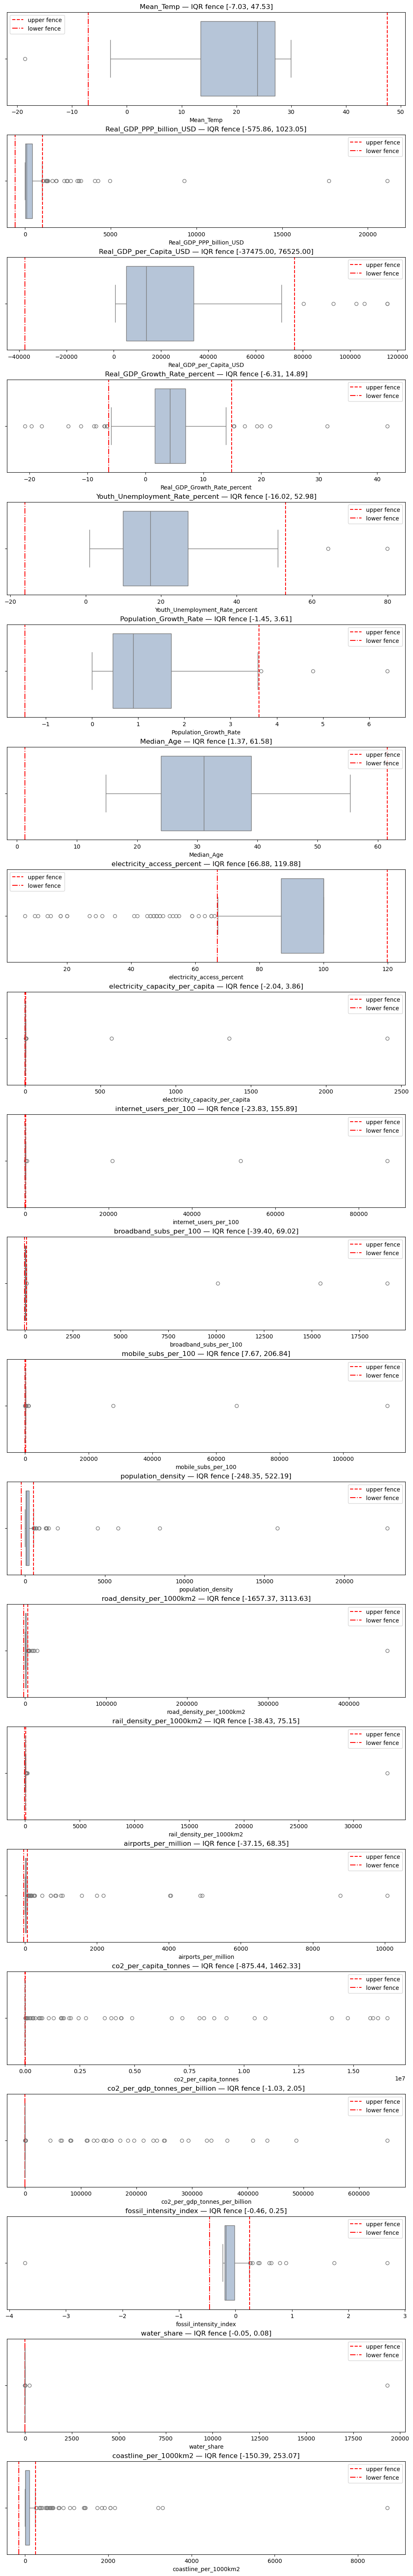

Countries outside the IQR fences:
co2_per_gdp_tonnes_per_billion     48
co2_per_capita_tonnes              48
electricity_access_percent         37
airports_per_million               36
coastline_per_1000km2              35
Real_GDP_PPP_billion_USD           25
water_share                        19
Real_GDP_Growth_Rate_percent       19
road_density_per_1000km2           18
population_density                 18
fossil_intensity_index             12
electricity_capacity_per_capita    10
mobile_subs_per_100                10
rail_density_per_1000km2           10
Real_GDP_per_Capita_USD             6
internet_users_per_100              5
broadband_subs_per_100              4
Population_Growth_Rate              3
Youth_Unemployment_Rate_percent     2
Mean_Temp                           1
dtype: int64


In [24]:
# categorical missingness (object columns already covered before if needed)
cat_cols = df_final.select_dtypes(include="object").columns
for col in cat_cols:
    display(df_final[col].fillna("Missing").value_counts().head(10))
    print(f"{col} missing: {df_final[col].isna().sum()} rows")
    print("-" * 80)

# compute IQR thresholds
num_cols = df_final.select_dtypes(include="number").columns
iqr = df_final[num_cols].quantile(0.75) - df_final[num_cols].quantile(0.25)
upper = df_final[num_cols].quantile(0.75) + 1.5 * iqr
lower = df_final[num_cols].quantile(0.25) - 1.5 * iqr

fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, 3 * len(num_cols)), constrained_layout=True)
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df_final[col], ax=ax, color="lightsteelblue")
    ax.set_title(f"{col} — IQR fence [{lower[col]:.2f}, {upper[col]:.2f}]")
    ax.axvline(upper[col], color="red", linestyle="--", label="upper fence")
    ax.axvline(lower[col], color="red", linestyle="-.", label="lower fence")
    ax.legend()
plt.show()

outlier_counts = (
    df_final[num_cols]
    .apply(lambda col: ((col > upper[col.name]) | (col < lower[col.name])).sum())
    .sort_values(ascending=False)
)
print("Countries outside the IQR fences:")
print(outlier_counts[outlier_counts > 0])

In [25]:
missing_literacy = (
    df_final[df_final["Total_Literacy_Rate"].isna()]
    [["Country"]]
    .drop_duplicates()
    .sort_values("Country")
)
print("Countries missing Total_Literacy_Rate:")
print(missing_literacy.to_string(index=False))

Countries missing Total_Literacy_Rate:
                                      Country
                               AMERICAN SAMOA
                                     ANGUILLA
                                    AUSTRALIA
                                      AUSTRIA
                                 BAHAMAS, THE
                                      BELGIUM
                                       BELIZE
                                      BERMUDA
                       BRITISH VIRGIN ISLANDS
                                       CANADA
                                      CURACAO
                                      DENMARK
                                     DJIBOUTI
                                     DOMINICA
                                FAROE ISLANDS
                                      FINLAND
                             FRENCH POLYNESIA
                                      GERMANY
                                    GIBRALTAR
                                         

C:\Users\muham\AppData\Local\Temp\ipykernel_19088\2141649765.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\2141649765.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\2141649765.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\2141649765.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

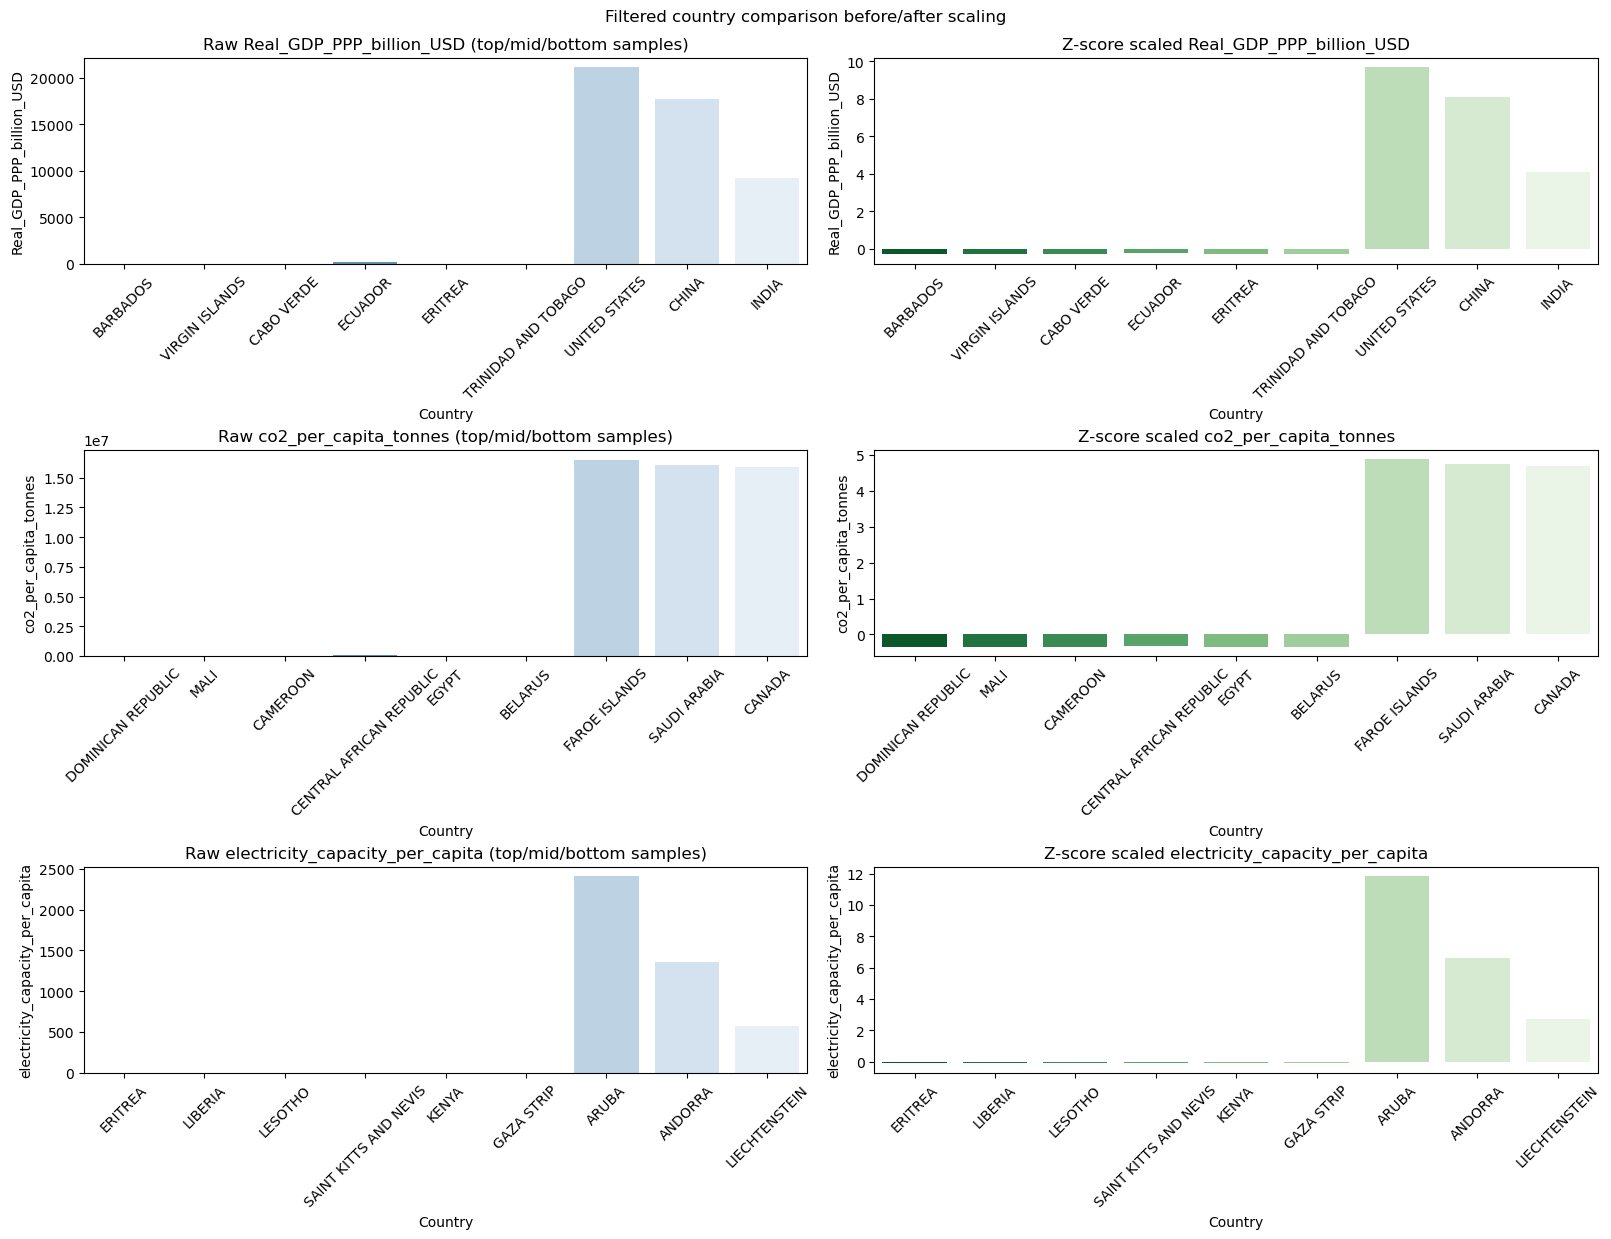

In [26]:
selected_metrics = ["Real_GDP_PPP_billion_USD", "co2_per_capita_tonnes", "electricity_capacity_per_capita"]
scaled = (df_final[selected_metrics] - df_final[selected_metrics].mean()) / df_final[selected_metrics].std()

fig, axes = plt.subplots(3, 2, figsize=(16, 12), constrained_layout=True)

for row, col in enumerate(selected_metrics):
    quantiles = df_final[col].quantile([0.1, 0.5, 0.9])
    buckets = [
        df_final[df_final[col] <= quantiles.loc[0.1]].nlargest(3, col),
        df_final[(df_final[col] > quantiles.loc[0.1]) & (df_final[col] < quantiles.loc[0.9])].sample(3, random_state=1),
        df_final[df_final[col] >= quantiles.loc[0.9]].nlargest(3, col),
    ]
    subset = pd.concat(buckets)
    sns.barplot(x="Country", y=col, data=subset, ax=axes[row, 0], palette="Blues_r")
    axes[row, 0].set_title(f"Raw {col} (top/mid/bottom samples)")
    axes[row, 0].tick_params(axis="x", rotation=45)

    subset_scaled = subset.assign(**{col: scaled.loc[subset.index, col]})
    sns.barplot(x="Country", y=col, data=subset_scaled, ax=axes[row, 1], palette="Greens_r")
    axes[row, 1].set_title(f"Z-score scaled {col}")
    axes[row, 1].tick_params(axis="x", rotation=45)

plt.suptitle("Filtered country comparison before/after scaling", y=1.02)
plt.show()

In [27]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

selected_metrics = [
    "Real_GDP_PPP_billion_USD",
    "co2_per_capita_tonnes",
    "electricity_capacity_per_capita",
]

scalers = {
    "Z-score": (df_final[selected_metrics] - df_final[selected_metrics].mean()) / df_final[selected_metrics].std(),
    "Robust": pd.DataFrame(
        RobustScaler().fit_transform(df_final[selected_metrics]),
        index=df_final.index,
        columns=selected_metrics,
    ),
    "Min-Max": pd.DataFrame(
        MinMaxScaler().fit_transform(df_final[selected_metrics]),
        index=df_final.index,
        columns=selected_metrics,
    ),
}

C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

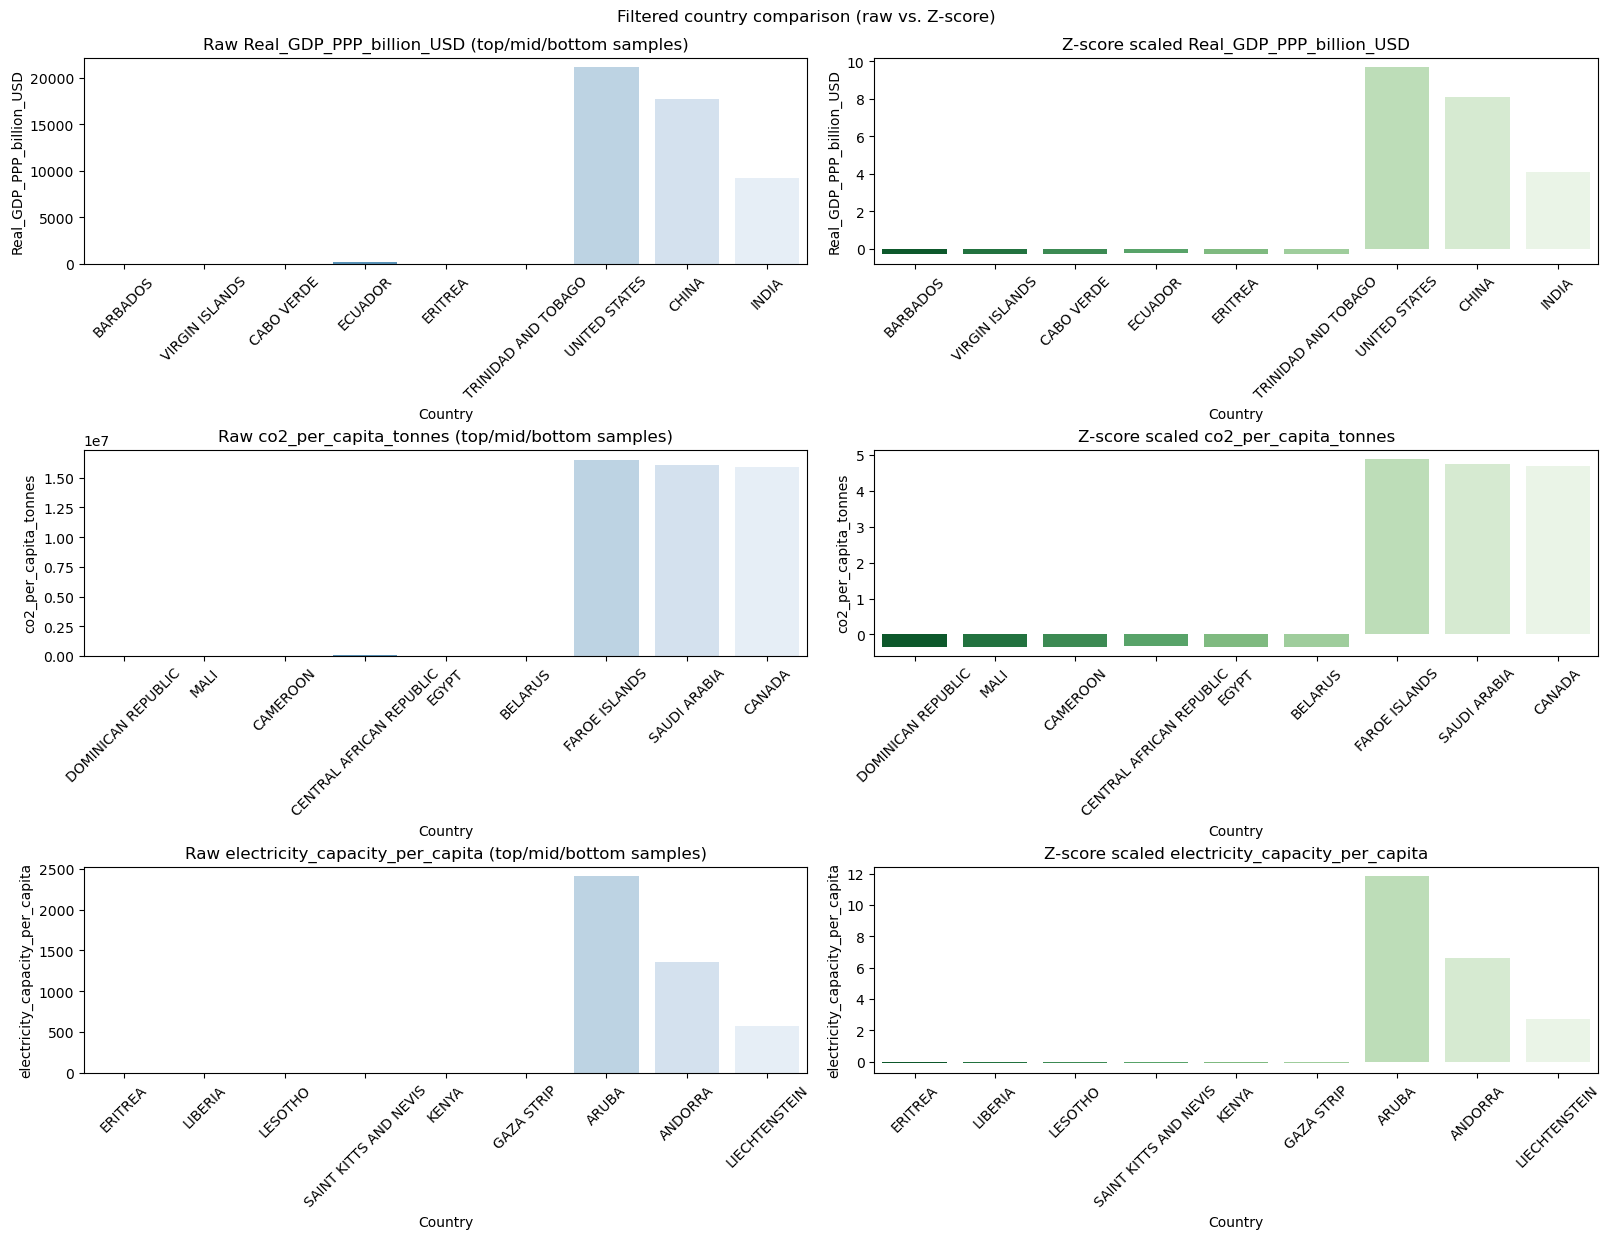

C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

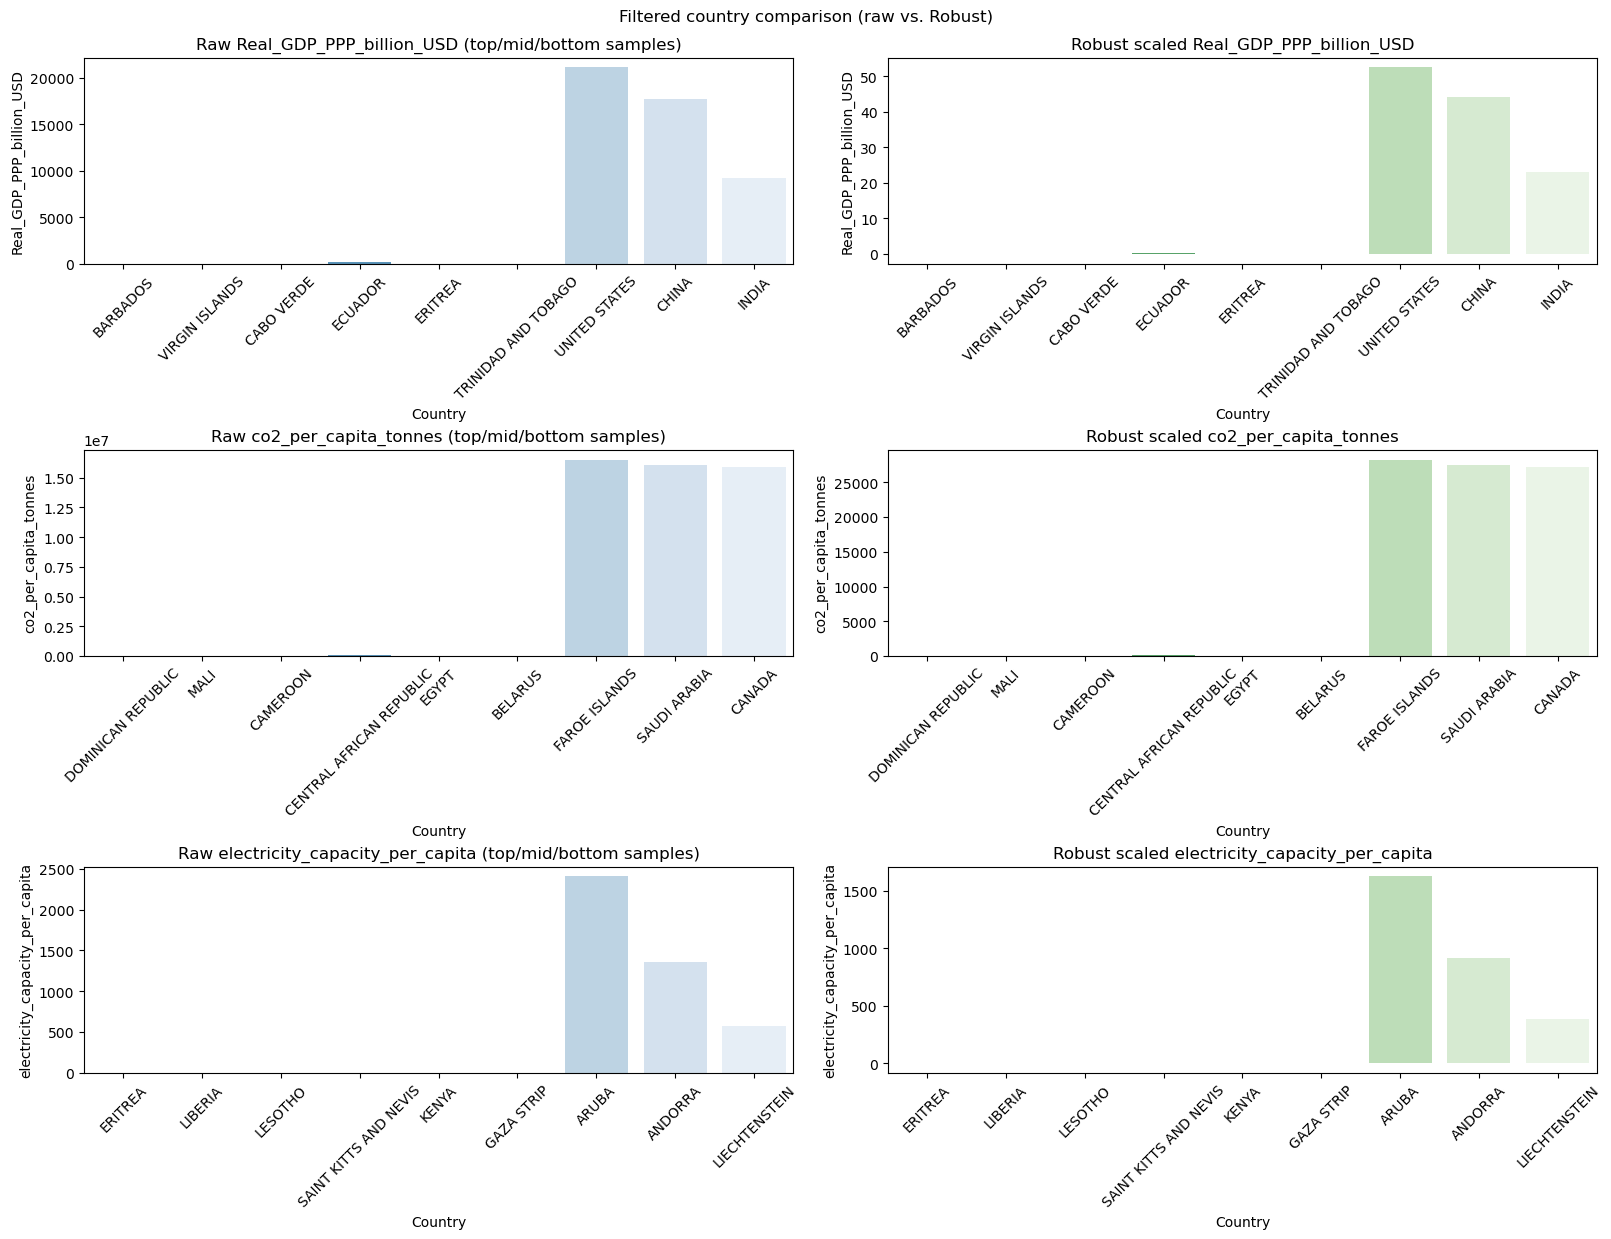

C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\muham\AppData\Local\Temp\ipykernel_19088\1754703958.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

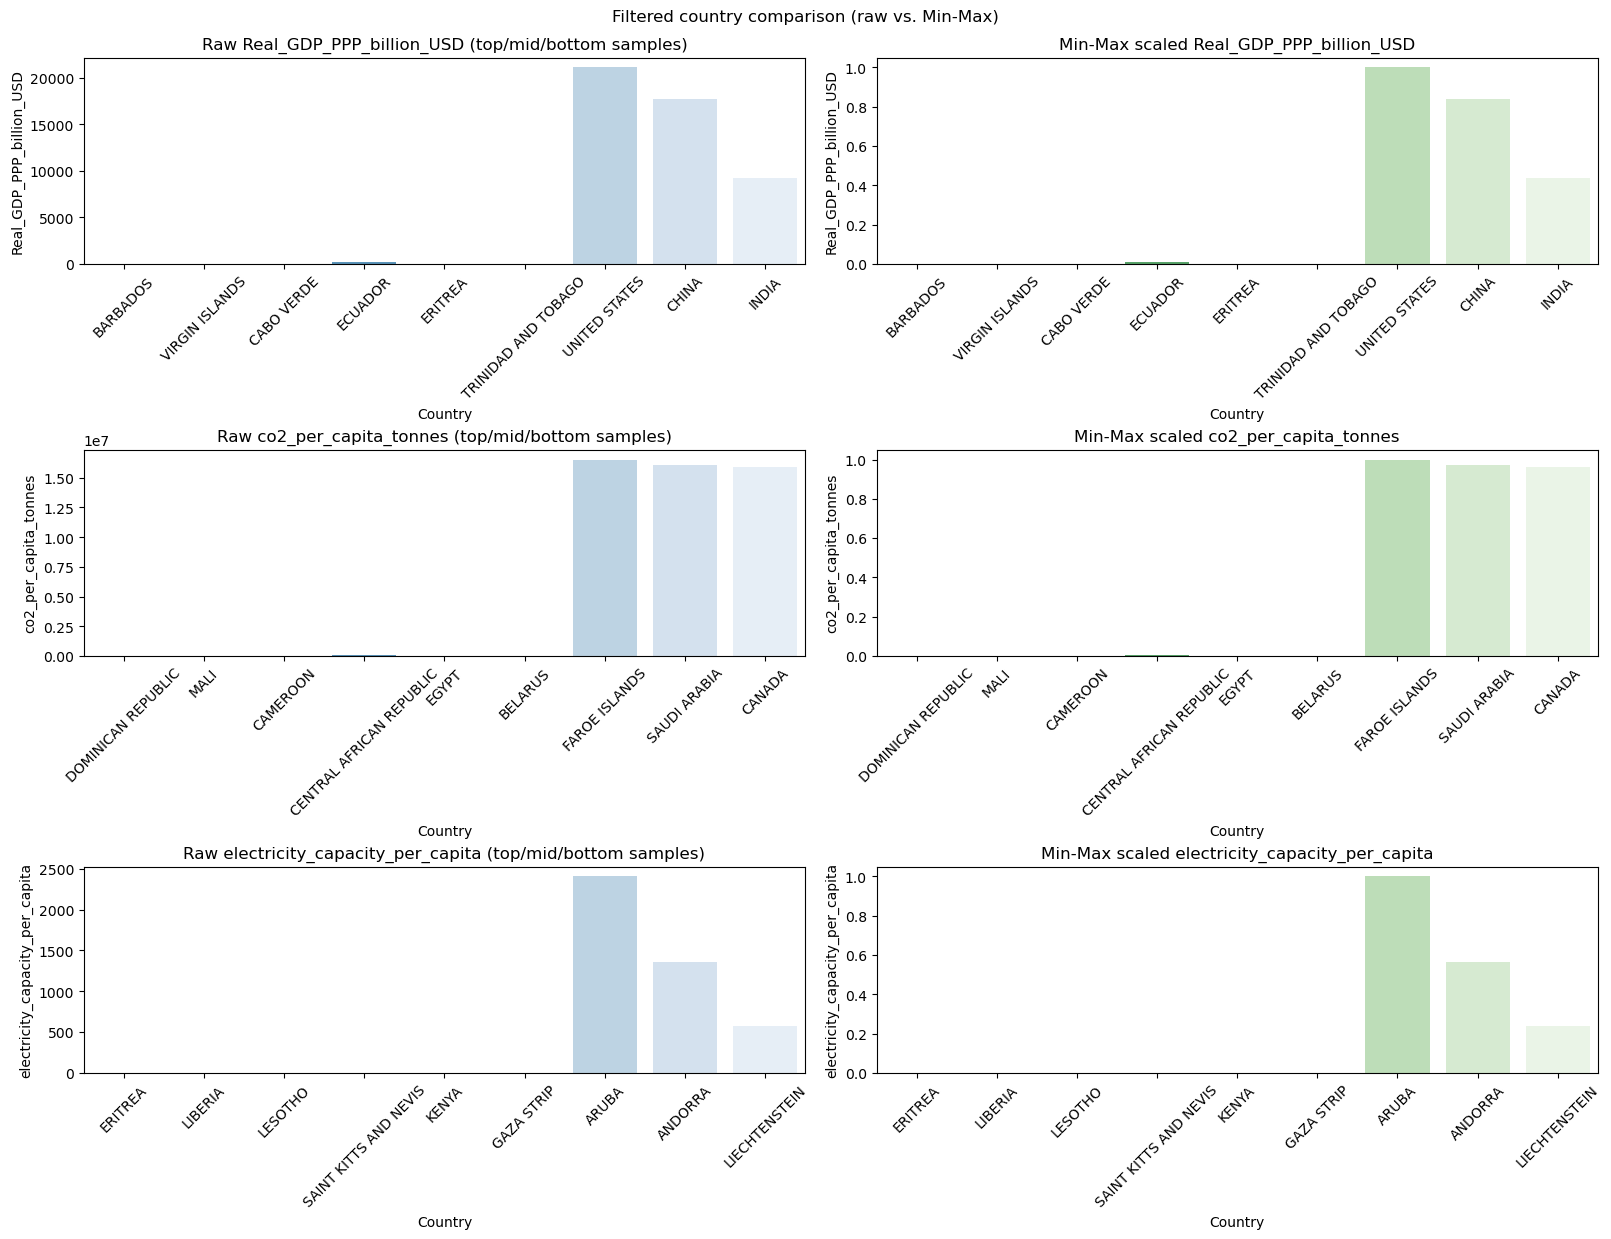

In [30]:
for scale_name, scaled in scalers.items():
    fig, axes = plt.subplots(len(selected_metrics), 2, figsize=(16, 12), constrained_layout=True)

    for row, col in enumerate(selected_metrics):
        quantiles = df_final[col].quantile([0.1, 0.5, 0.9])
        buckets = [
            df_final[df_final[col] <= quantiles.loc[0.1]].nlargest(3, col),
            df_final[
                (df_final[col] > quantiles.loc[0.1]) &
                (df_final[col] < quantiles.loc[0.9])
            ].sample(3, random_state=1),
            df_final[df_final[col] >= quantiles.loc[0.9]].nlargest(3, col),
        ]
        subset = pd.concat(buckets)

        sns.barplot(
            x="Country",
            y=col,
            data=subset,
            ax=axes[row, 0],
            palette="Blues_r",
        )
        axes[row, 0].set_title(f"Raw {col} (top/mid/bottom samples)")
        axes[row, 0].tick_params(axis="x", rotation=45)

        subset_scaled = subset.assign(**{col: scaled.loc[subset.index, col]})
        sns.barplot(
            x="Country",
            y=col,
            data=subset_scaled,
            ax=axes[row, 1],
            palette="Greens_r",
        )
        axes[row, 1].set_title(f"{scale_name} scaled {col}")
        axes[row, 1].tick_params(axis="x", rotation=45)

    plt.suptitle(f"Filtered country comparison (raw vs. {scale_name})", y=1.02)
    plt.show()